# ERCOT Texas Grid Load Analysis (2018-2024)

Analysis of 7 years of hourly electricity load data across 8 ERCOT weather zones,
covering 58,000+ records to identify long-term demand trends, seasonal patterns,
regional correlations, and grid vulnerabilities under extreme weather.

**Data source:** ERCOT Hourly Load Data Archives (https://www.ercot.com/gridinfo/load/load_hist)

**Key analyses:**
1. Long-term statewide demand growth and data center impact
2. Houston hourly load profile
3. Regional load share across 8 weather zones
4. Winter Storm Uri (Feb 2021) demand surge and grid collapse
5. Houston-Dallas correlation and coordinated peak stress
6. Seasonal peak timing (summer vs winter)

## 1. Setup and Data Loading

Load all 8 yearly ERCOT Native Load files and combine them into a single
DataFrame. The column naming convention changed across years (`HourEnding` in
2018-2020, `Hour Ending` with a space in 2021-2024), so we normalize column
names before concatenation.

In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

files = sorted(glob.glob(os.path.join(DATA_DIR, "Native_Load_*.xlsx")))
print(f"Found {len(files)} data files:")
for f in files:
    print(f"  - {os.path.basename(f)}")

Found 7 data files:
  - Native_Load_2018.xlsx
  - Native_Load_2019.xlsx
  - Native_Load_2020.xlsx
  - Native_Load_2021.xlsx
  - Native_Load_2022.xlsx
  - Native_Load_2023.xlsx
  - Native_Load_2024.xlsx


In [2]:
dfs = []
for f in files:
    df = pd.read_excel(f)
    # Normalize column names: "Hour Ending" -> "HourEnding"
    df.columns = df.columns.str.strip().str.replace(" ", "")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {df_all.shape}")
print(f"Columns: {df_all.columns.tolist()}")

Combined shape: (61368, 10)
Columns: ['HourEnding', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT', 'WEST', 'ERCOT']


## 2. Data Cleaning and Feature Engineering

Parse the timestamp column, drop invalid rows, and extract year, month, and
hour components for time-series analysis.

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df_all["HourEnding"] = pd.to_datetime(df_all["HourEnding"], errors="coerce")
df_all = df_all.dropna(subset=["HourEnding"])

df_all["year"] = df_all["HourEnding"].dt.year
df_all["month"] = df_all["HourEnding"].dt.month
df_all["hour"] = df_all["HourEnding"].dt.hour

print(f"Clean shape: {df_all.shape}")
print(f"\nRecords per year:")
print(df_all["year"].value_counts().sort_index())

Clean shape: (58811, 13)

Records per year:
2018    8395
2019    8395
2020    8418
2021    8395
2022    8395
2023    8395
2024    8418
Name: year, dtype: int64


## 3. Analysis 1 — Long-Term Statewide Growth Trend

Compute annual average hourly load for the ERCOT system as a whole, then measure
year-over-year growth rates. The goal is to detect whether the post-2022 era
(large-scale data center expansion across Texas) produced a structural shift
in demand growth.

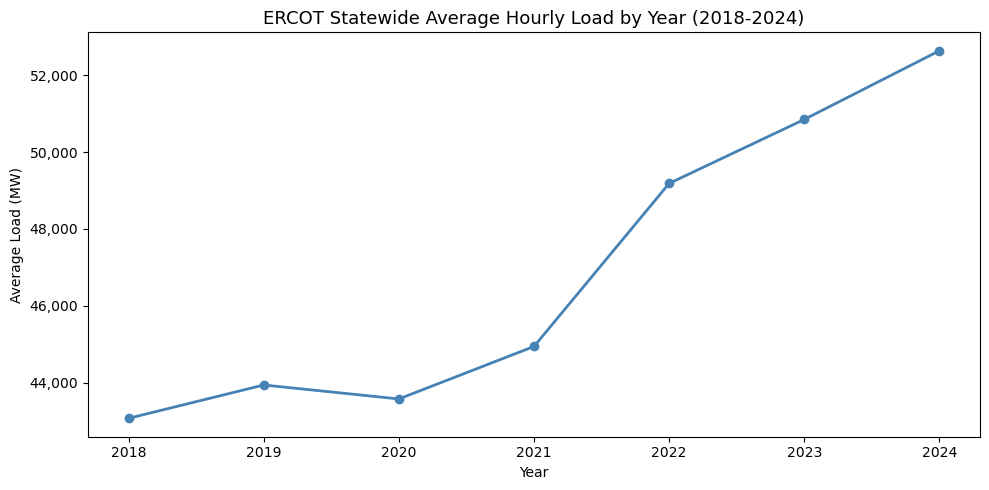

Year-over-year growth rate (%):
year
2018     NaN
2019    2.02
2020   -0.83
2021    3.14
2022    9.45
2023    3.39
2024    3.52
Name: ERCOT, dtype: float64

Pre-2022 avg growth: 1.44%
Post-2022 avg growth: 5.45%
Post-2022 acceleration: 3.8x baseline
Total 2018-2024 growth: 22.2%


In [5]:
yearly_ercot = df_all.groupby("year")["ERCOT"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_ercot.index, yearly_ercot.values,
        marker="o", linewidth=2, color="steelblue")
ax.set_title("ERCOT Statewide Average Hourly Load by Year (2018-2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Average Load (MW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ercot_yearly_trend.png"), dpi=150)
plt.show()

yoy_ercot = yearly_ercot.pct_change() * 100
pre_2022 = yoy_ercot.loc[2019:2021].mean()
post_2022 = yoy_ercot.loc[2022:2024].mean()
total_growth = (yearly_ercot.loc[2024] / yearly_ercot.loc[2018] - 1) * 100

print("Year-over-year growth rate (%):")
print(yoy_ercot.round(2))
print(f"\nPre-2022 avg growth: {pre_2022:.2f}%")
print(f"Post-2022 avg growth: {post_2022:.2f}%")
print(f"Post-2022 acceleration: {post_2022 / pre_2022:.1f}x baseline")
print(f"Total 2018-2024 growth: {total_growth:.1f}%")

**Finding 1:** Statewide ERCOT demand grew **22.2%** over 2018-2024. Year-over-year growth reveals two inflection points: a **COVID-driven dip in 2020 (−0.83%)** and a **sudden acceleration starting 2022 (+9.45%)**. Post-2022 annual growth averaged **5.45%**, roughly **3.8x** the pre-2022 baseline of **1.44%**, consistent with the timeline of major data center openings (Meta/Fort Worth 2022, Amazon/Dallas 2022, Microsoft 2023, xAI 2024).

## 4. Analysis 2 — Houston Hourly Load Profile

Average hourly load in the COAST zone (Houston region) across the full 8-year
window to identify daily peak hours and peak-to-trough swing.

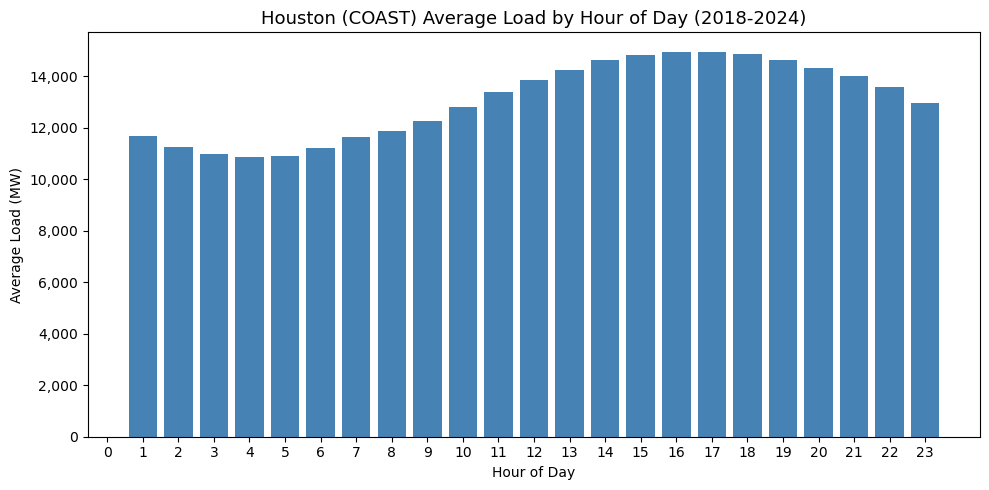

Peak hour: 17:00 (14,951 MW)
Trough hour: 4:00 (10,854 MW)
Peak-to-trough swing: 37.7%


In [6]:
hourly_coast = df_all.groupby("hour")["COAST"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_coast.index, hourly_coast.values, color="steelblue")
ax.set_title("Houston (COAST) Average Load by Hour of Day (2018-2024)", fontsize=13)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Load (MW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "houston_hourly_pattern.png"), dpi=150)
plt.show()

peak_hour = hourly_coast.idxmax()
trough_hour = hourly_coast.idxmin()
swing_pct = (hourly_coast.max() - hourly_coast.min()) / hourly_coast.min() * 100
print(f"Peak hour: {peak_hour}:00 ({hourly_coast.max():,.0f} MW)")
print(f"Trough hour: {trough_hour}:00 ({hourly_coast.min():,.0f} MW)")
print(f"Peak-to-trough swing: {swing_pct:.1f}%")

**Finding 2:** Houston load peaks at **17:00** (14,951 MW) and bottoms out at **4:00 AM** (10,854 MW) — a **37.7% peak-to-trough swing** that defines the daily capacity cycle.

## 5. Analysis 3 — Regional Load Share

Compute each weather zone's share of total ERCOT load to quantify geographic
concentration.

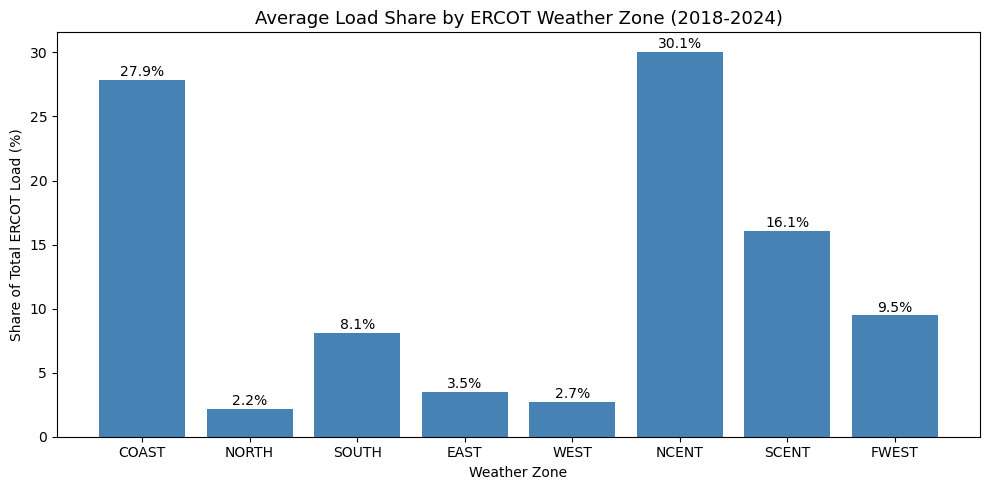

NCENT    30.1
COAST    27.9
SCENT    16.1
FWEST     9.5
SOUTH     8.1
EAST      3.5
WEST      2.7
NORTH     2.2
dtype: float64


In [7]:
zones = ["COAST", "NORTH", "SOUTH", "EAST", "WEST", "NCENT", "SCENT", "FWEST"]
zone_avg = df_all[zones].mean()
zone_pct = zone_avg / df_all["ERCOT"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zone_pct.index, zone_pct.values, color="steelblue")
ax.set_title("Average Load Share by ERCOT Weather Zone (2018-2024)", fontsize=13)
ax.set_xlabel("Weather Zone")
ax.set_ylabel("Share of Total ERCOT Load (%)")
for bar, val in zip(bars, zone_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ercot_zone_share.png"), dpi=150)
plt.show()

print(zone_pct.round(1).sort_values(ascending=False))

**Finding 3:** COAST (Houston) and NCENT (Dallas-Fort Worth) together account
for over half of statewide load, making their coordinated behavior the primary
driver of grid stress.

## 6. Analysis 4 — Winter Storm Uri Impact (Feb 2021)

Isolate February 2021 COAST load during Winter Storm Uri and compare against
the average February load across non-2021 years. This captures both the initial
demand surge (heating) and the subsequent collapse (forced outages).

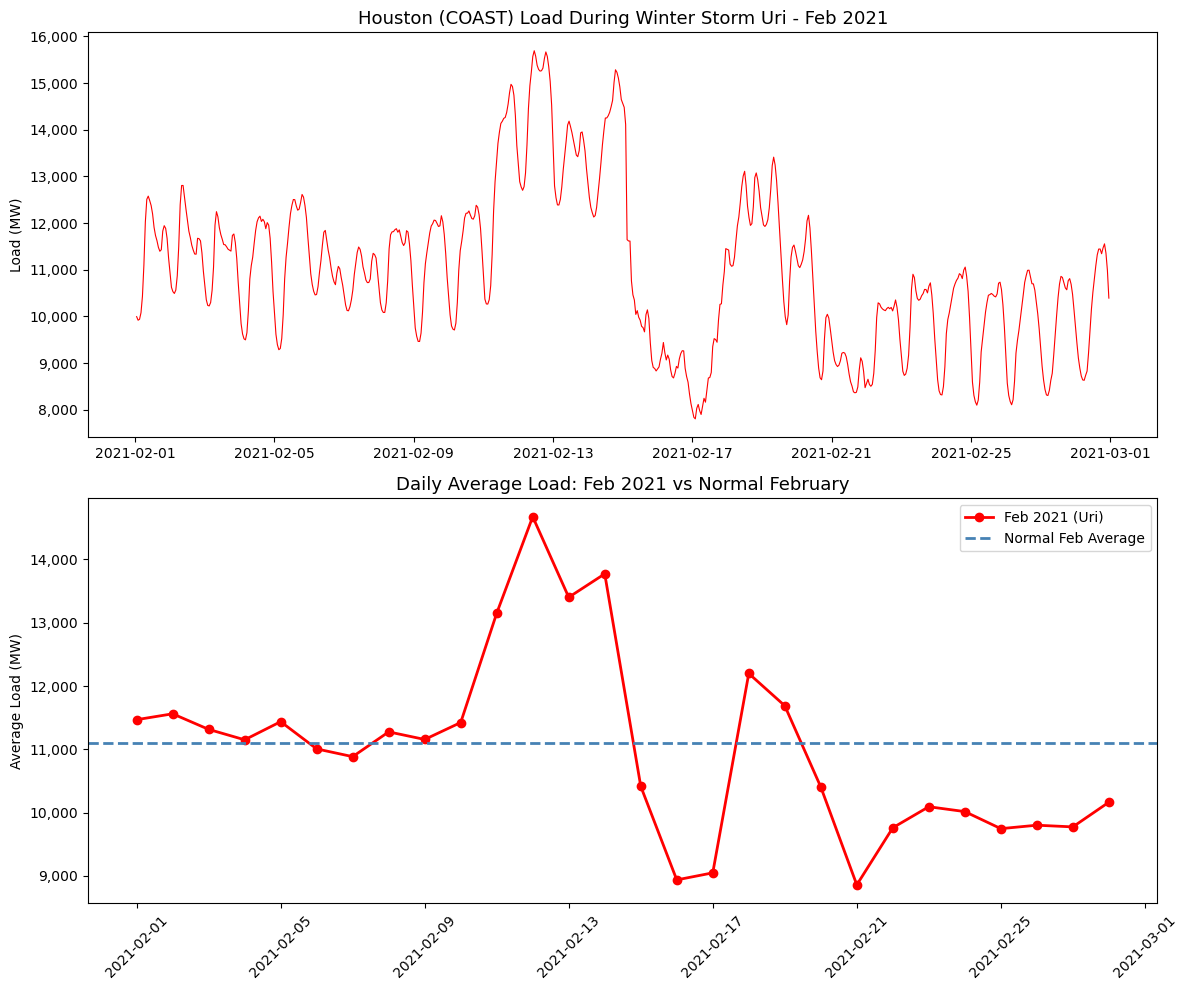

Normal Feb average:  11,099 MW
Uri peak demand:     15,692 MW  (+41.4% vs normal)
Uri lowest demand:   7,804 MW  (supply collapse)


In [8]:
uri = df_all[(df_all["year"] == 2021) & (df_all["month"] == 2)]
normal_feb = df_all[(df_all["month"] == 2) & (df_all["year"] != 2021)].groupby("hour")["COAST"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(uri["HourEnding"], uri["COAST"], color="red", linewidth=0.8)
axes[0].set_title("Houston (COAST) Load During Winter Storm Uri - Feb 2021", fontsize=13)
axes[0].set_ylabel("Load (MW)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

feb_2021_daily = uri.groupby(uri["HourEnding"].dt.date)["COAST"].mean()
axes[1].plot(feb_2021_daily.index, feb_2021_daily.values,
             color="red", marker="o", linewidth=2, label="Feb 2021 (Uri)")
axes[1].axhline(y=normal_feb.mean(), color="steelblue",
                linestyle="--", linewidth=2, label="Normal Feb Average")
axes[1].set_title("Daily Average Load: Feb 2021 vs Normal February", fontsize=13)
axes[1].set_ylabel("Average Load (MW)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "uri_analysis.png"), dpi=150)
plt.show()

surge_pct = (uri["COAST"].max() / normal_feb.mean() - 1) * 100
print(f"Normal Feb average:  {normal_feb.mean():,.0f} MW")
print(f"Uri peak demand:     {uri['COAST'].max():,.0f} MW  (+{surge_pct:.1f}% vs normal)")
print(f"Uri lowest demand:   {uri['COAST'].min():,.0f} MW  (supply collapse)")

**Finding 4:** Demand surged **41.4%** above the normal February baseline (15,692 MW peak vs. 11,099 MW normal), then collapsed to **7,804 MW** as the grid failed. This is an empirical benchmark for capacity-reserve planning under extreme-cold scenarios.

## 7. Analysis 5 — COAST vs NCENT Peak Synchronization

Compare hourly load profiles and overall correlation between the two largest
zones to determine whether peak demand arrives at the same time (compounding
grid stress) or staggers (allowing load-balancing).

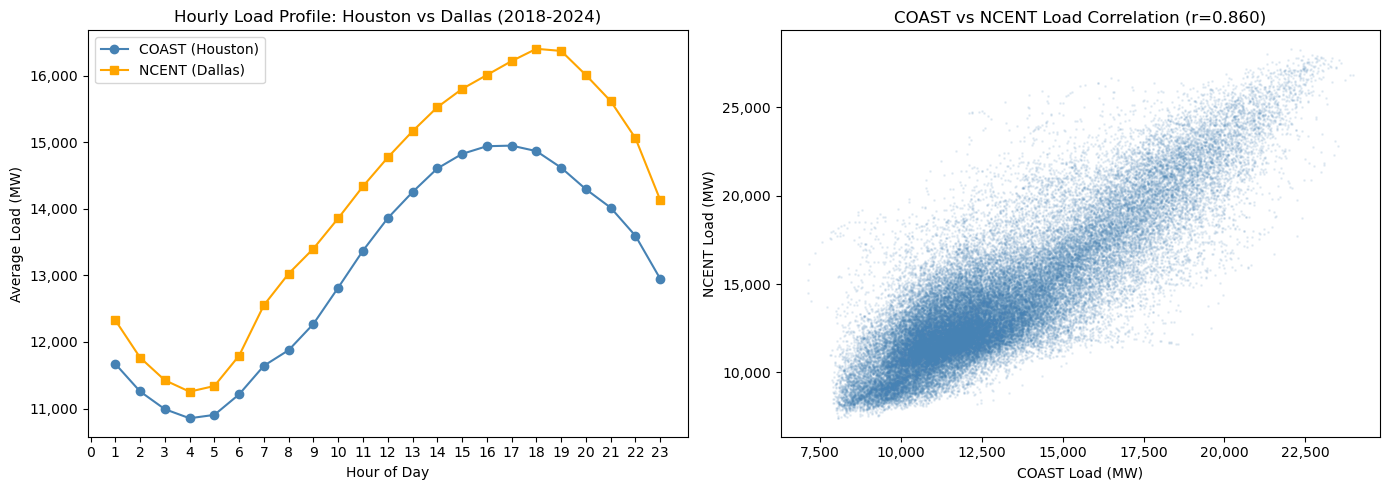

Correlation coefficient: 0.860
COAST peak hour: 17:00
NCENT peak hour: 18:00


In [9]:
hourly_zones = df_all.groupby("hour")[["COAST", "NCENT"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_zones.index, hourly_zones["COAST"],
             marker="o", label="COAST (Houston)", color="steelblue")
axes[0].plot(hourly_zones.index, hourly_zones["NCENT"],
             marker="s", label="NCENT (Dallas)", color="orange")
axes[0].set_title("Hourly Load Profile: Houston vs Dallas (2018-2024)", fontsize=12)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Load (MW)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_xticks(range(0, 24))
axes[0].legend()

corr = df_all["COAST"].corr(df_all["NCENT"])
axes[1].scatter(df_all["COAST"], df_all["NCENT"], alpha=0.1, color="steelblue", s=1)
axes[1].set_title(f"COAST vs NCENT Load Correlation (r={corr:.3f})", fontsize=12)
axes[1].set_xlabel("COAST Load (MW)")
axes[1].set_ylabel("NCENT Load (MW)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "zone_correlation.png"), dpi=150)
plt.show()

print(f"Correlation coefficient: {corr:.3f}")
print(f"COAST peak hour: {hourly_zones['COAST'].idxmax()}:00")
print(f"NCENT peak hour: {hourly_zones['NCENT'].idxmax()}:00")

**Finding 5:** The two largest zones are highly correlated (**r = 0.860**) with peaks just **one hour apart** (17:00 Houston vs 18:00 Dallas). Grid stress compounds during a narrow 17:00-18:00 window, a structural constraint on dispatch flexibility.

## 8. Analysis 6 — Summer vs Winter Peak Timing

Compare hourly profiles in summer months (Jun-Aug) against winter months
(Dec-Feb) to quantify seasonal shift in peak demand timing.

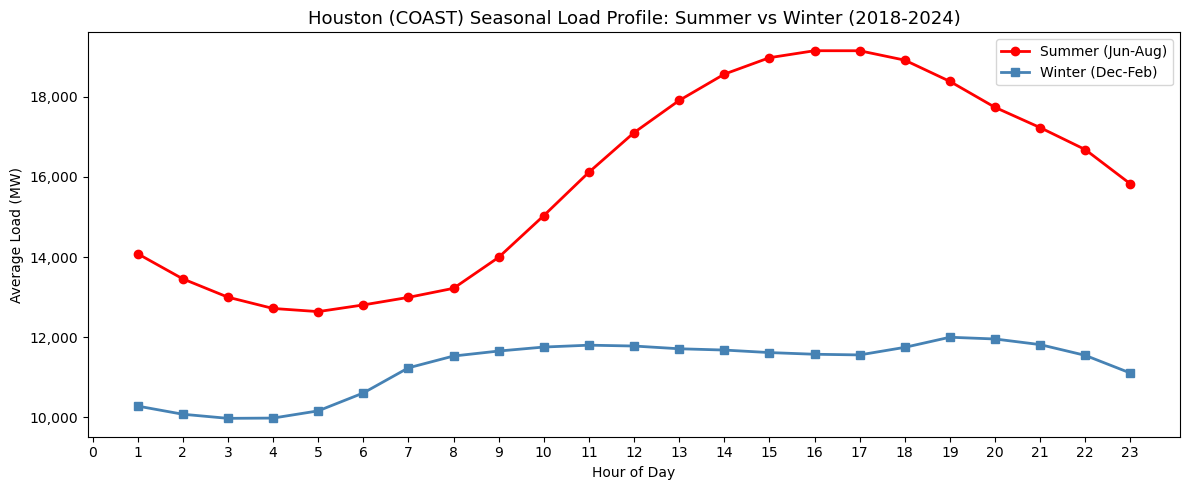

Summer peak hour: 16:00 (19,151 MW)
Winter peak hour: 19:00 (12,001 MW)
Seasonal peak difference: 7,150 MW (59.6%)


In [10]:
summer = df_all[df_all["month"].isin([6, 7, 8])].groupby("hour")["COAST"].mean()
winter = df_all[df_all["month"].isin([12, 1, 2])].groupby("hour")["COAST"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(summer.index, summer.values, marker="o",
        label="Summer (Jun-Aug)", color="red", linewidth=2)
ax.plot(winter.index, winter.values, marker="s",
        label="Winter (Dec-Feb)", color="steelblue", linewidth=2)
ax.set_title("Houston (COAST) Seasonal Load Profile: Summer vs Winter (2018-2024)", fontsize=13)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Load (MW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "seasonal_pattern.png"), dpi=150)
plt.show()

diff = summer.max() - winter.max()
diff_pct = diff / winter.max() * 100
print(f"Summer peak hour: {summer.idxmax()}:00 ({summer.max():,.0f} MW)")
print(f"Winter peak hour: {winter.idxmax()}:00 ({winter.max():,.0f} MW)")
print(f"Seasonal peak difference: {diff:,.0f} MW ({diff_pct:.1f}%)")

**Finding 6:** Summer peak occurs at **16:00 (19,151 MW)** while winter peak shifts to **19:00 (12,001 MW)** — a **7,150 MW seasonal gap (59.6%)** and a 3-hour timing shift. Capacity procurement and dispatch strategy need to flip between the two regimes.

## Summary of Key Findings

| # | Finding | Strategic Implication |
|---|---------|----------------------|
| 1 | Statewide demand grew 22.2% (2018-2024); post-2022 growth is 3.8x baseline | Long-term capacity expansion planning must account for structural demand shift driven by data centers |
| 2 | Houston daily swing of 37.7% between trough (10,854 MW) and peak (14,951 MW at 17:00) | Informs day-ahead dispatch and peaker-plant scheduling |
| 3 | COAST and NCENT together dominate statewide load | Investment and reliability focus should concentrate on these two zones |
| 4 | Winter Storm Uri: +41.4% demand surge, then collapse to 7,804 MW | Empirical benchmark for winter reserve-margin sizing and weatherization ROI |
| 5 | Houston-Dallas correlation r = 0.860, peaks 1 hour apart | Grid stress compounds in a narrow 17:00-18:00 window, constraining dispatch flexibility |
| 6 | Summer peak 16:00 (19,151 MW) vs winter peak 19:00 (12,001 MW); 59.6% gap | Procurement and dispatch strategy must flip seasonally |